# Vintage Vestige — Enriched Data EDA

Exploring 1,000 enriched items across 3 sources: Met Museum, Smithsonian, Fashionpedia.
Each item has been through Claude enrichment (full or creative-only) with structured taxonomy fields + AI-generated creative metadata.

In [30]:
import sys
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.facecolor'] = '#fdf6ee'
matplotlib.rcParams['axes.facecolor'] = '#fdf6ee'
matplotlib.rcParams['font.family'] = 'serif'

# Vintage Vestige color palette
VV_COLORS = {
    'cream': '#fdf6ee',
    'burgundy': '#722f37',
    'sage': '#87ae73',
    'taupe': '#8b7d6b',
    'gold': '#c5a55a',
    'navy': '#2c3e50',
    'rose': '#c48b9f',
}
PALETTE = [VV_COLORS['burgundy'], VV_COLORS['sage'], VV_COLORS['gold'], VV_COLORS['taupe'], VV_COLORS['navy'], VV_COLORS['rose']]

sys.path.insert(0, os.path.abspath('../scripts'))
from storage.database import SessionLocal, Product

db = SessionLocal()
products = db.query(Product).all()
print(f'Total products: {len(products)}')

Total products: 952


In [31]:
# Build a DataFrame from the products
rows = []
for p in products:
    rows.append({
        'id': p.id,
        'title': p.title,
        'platform': p.platform,
        'category': p.category,
        'era': p.era,
        'decade': p.decade,
        'material': p.material,
        'pattern': p.pattern,
        'vibe': p.vibe,
        'fit_style': p.fit_style,
        'occasion': p.occasion,
        'garment_type': p.garment_type,
        'culture': p.culture,
        'period': p.period,
        'object_date': p.object_date,
        'fp_category': p.fp_category,
        'silhouette': p.silhouette,
        'neckline': p.neckline,
        'waistline': p.waistline,
        'length': p.length,
        'sleeve_length': p.sleeve_length,
        'opening_type': p.opening_type,
        'textile_pattern': p.textile_pattern,
        'nickname': p.nickname,
        'ai_description': p.ai_description,
        'style_tags': json.loads(p.style_tags) if p.style_tags else [],
        'colors': json.loads(p.colors) if p.colors else [],
        'textile_finishing': json.loads(p.textile_finishing) if p.textile_finishing else [],
        'garment_parts': json.loads(p.garment_parts) if p.garment_parts else [],
        'decorations': json.loads(p.decorations) if p.decorations else [],
        'has_image': p.primary_image is not None and len(p.primary_image or '') > 0,
        'has_enrichment': p.enriched_at is not None,
        'has_ai_description': p.ai_description is not None and len(p.ai_description or '') > 0,
    })

df = pd.DataFrame(rows)
print(f'DataFrame shape: {df.shape}')
df.head()

DataFrame shape: (952, 33)


,id,title,platform,category,era,decade,material,pattern,vibe,fit_style,...,nickname,ai_description,style_tags,colors,textile_finishing,garment_parts,decorations,has_image,has_enrichment,has_ai_description
0,1078,The Cup of Tea,smithsonian,Lithographs,NaN,NaN,hand-colored (image production method/technique),NaN,NaN,NaN,...,NaN,NaN,"[Tea Drinking, Art, Adornment, Food habits, Cl...",[],[],[],[],True,False,False
1,1079,The Belle of Ohio,smithsonian,Lithographs,NaN,NaN,paper (overall material),NaN,NaN,NaN,...,NaN,NaN,"[Art, Adornment, Clothing and dress, Dress acc...",[],[],[],[],True,False,False
2,1080,Fanny Elssler as Sylphyed,smithsonian,Lithographs,NaN,NaN,paper (overall material),NaN,NaN,NaN,...,NaN,NaN,"[Art, Costume, Dance, Peters Prints, Flowers, ...",[],[],[],[],True,False,False
3,195,Bag,met_museum,Bag,Victorian,1870s-1880s,tooled leather,decorative hand-stitching,rustic sophistication,structured rectangular,...,NaN,This exquisite Victorian tooled leather handba...,"[Victorian, folk, rustic charm, grandmacore]","[cognac brown, golden tan, cream stitching]",[],[],[],True,True,True
4,52,Ensemble,met_museum,Ensemble,Victorian,1860s,wool and silk,striped with fringe trim,theatrical folk charm,fitted bodice with full skirt,...,NaN,This striking Victorian child's ensemble featu...,"[Victorian, maximalist, theatrical, folk, whim...","[burnt orange, cream, golden fringe]",[],[],[],True,True,True


## 1. Data Overview — What Do We Have?

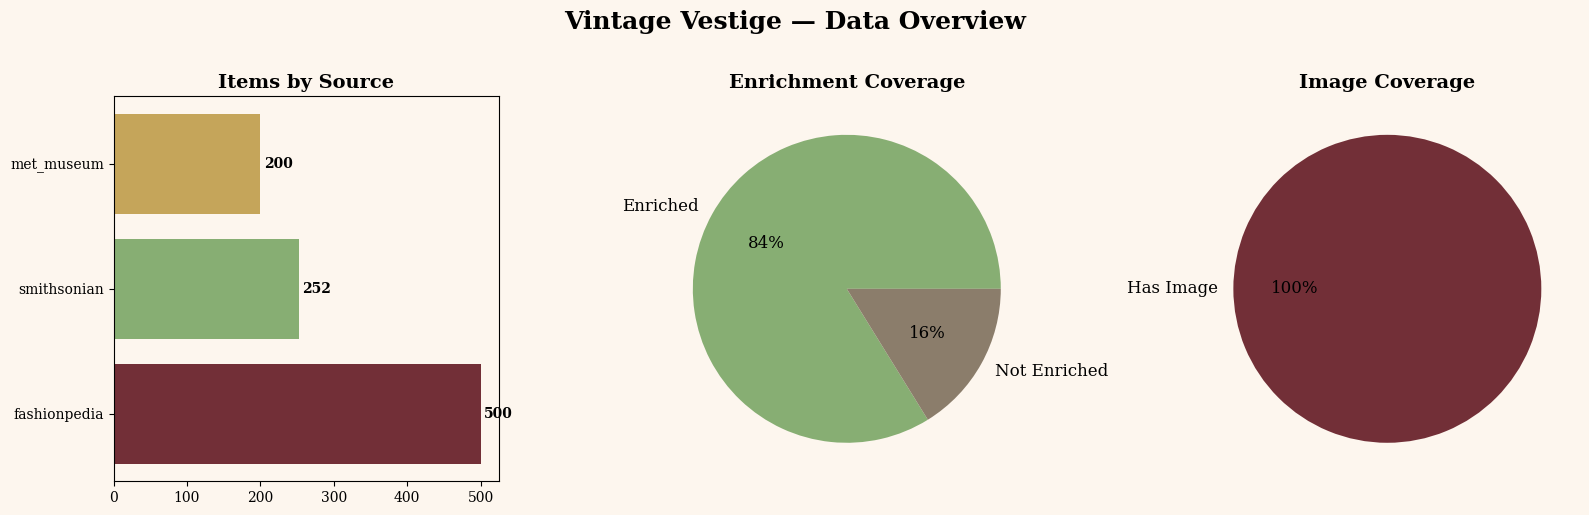

In [32]:
# Items by platform
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Platform distribution
platform_counts = df['platform'].value_counts()
axes[0].barh(platform_counts.index, platform_counts.values, color=PALETTE[:len(platform_counts)])
axes[0].set_title('Items by Source', fontsize=14, fontweight='bold')
for i, v in enumerate(platform_counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontweight='bold')

# Enrichment status
enrichment_counts = df['has_enrichment'].value_counts()
labels = ['Enriched' if k else 'Not Enriched' for k in enrichment_counts.index]
axes[1].pie(enrichment_counts.values, labels=labels, colors=[VV_COLORS['sage'], VV_COLORS['taupe']],
            autopct='%1.0f%%', textprops={'fontsize': 12})
axes[1].set_title('Enrichment Coverage', fontsize=14, fontweight='bold')

# Image availability
image_counts = df['has_image'].value_counts()
labels = ['Has Image' if k else 'No Image' for k in image_counts.index]
axes[2].pie(image_counts.values, labels=labels, colors=[VV_COLORS['burgundy'], VV_COLORS['taupe']],
            autopct='%1.0f%%', textprops={'fontsize': 12})
axes[2].set_title('Image Coverage', fontsize=14, fontweight='bold')

plt.suptitle('Vintage Vestige — Data Overview', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [33]:
# Field completeness by platform
taxonomy_fields = ['fp_category', 'silhouette', 'neckline', 'waistline', 'length',
                   'sleeve_length', 'opening_type', 'textile_pattern', 'nickname']
creative_fields = ['era', 'decade', 'vibe', 'fit_style', 'occasion', 'material', 'garment_type']

print('=== TAXONOMY FIELD COMPLETENESS (% non-null) ===')
print()
for platform in df['platform'].unique():
    subset = df[df['platform'] == platform]
    print(f'  {platform} ({len(subset)} items):')
    for field in taxonomy_fields:
        pct = (subset[field].notna() & (subset[field] != '')).mean() * 100
        bar = '#' * int(pct // 5)
        print(f'    {field:20s} {pct:5.1f}% {bar}')
    print()

print('=== CREATIVE FIELD COMPLETENESS (% non-null) ===')
print()
for platform in df['platform'].unique():
    subset = df[df['platform'] == platform]
    print(f'  {platform} ({len(subset)} items):')
    for field in creative_fields:
        pct = (subset[field].notna() & (subset[field] != '')).mean() * 100
        bar = '#' * int(pct // 5)
        print(f'    {field:20s} {pct:5.1f}% {bar}')
    print()

=== TAXONOMY FIELD COMPLETENESS (% non-null) ===

  smithsonian (252 items):
    fp_category           38.5% #######
    silhouette            34.1% ######
    neckline              19.8% ###
    waistline             30.2% ######
    length                31.7% ######
    sleeve_length         29.4% #####
    opening_type          22.2% ####
    textile_pattern       38.9% #######
    nickname              25.4% #####

  met_museum (200 items):
    fp_category            0.0% 
    silhouette             0.0% 
    neckline               0.0% 
    waistline              0.0% 
    length                 0.0% 
    sleeve_length          0.0% 
    opening_type           0.0% 
    textile_pattern        0.0% 
    nickname               0.0% 

  fashionpedia (500 items):
    fp_category          100.0% ####################
    silhouette            97.2% ###################
    neckline               0.0% 
    waistline             92.6% ##################
    length                80.2% ###

## 2. Temporal Distribution — What Eras Do We Cover?

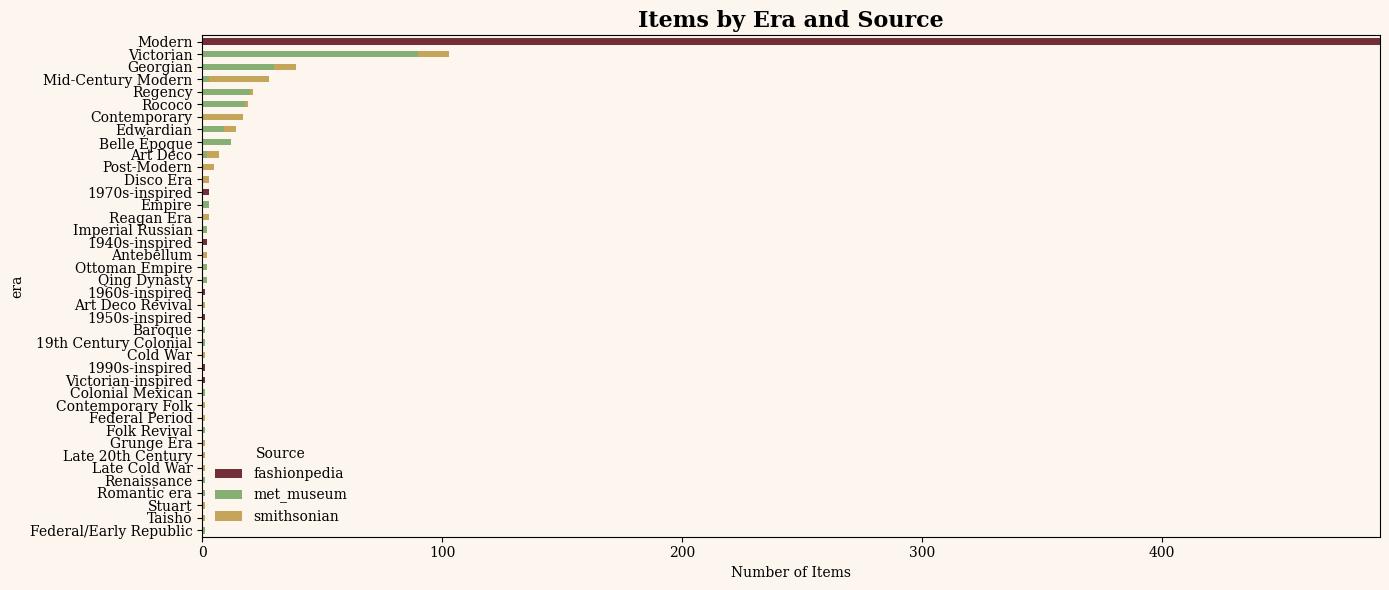

In [34]:
# Era distribution by platform
enriched = df[df['has_enrichment']].copy()

fig, ax = plt.subplots(figsize=(14, 6))

era_platform = enriched.groupby(['era', 'platform']).size().unstack(fill_value=0)
# Sort by total count
era_platform['total'] = era_platform.sum(axis=1)
era_platform = era_platform.sort_values('total', ascending=True).drop('total', axis=1)

era_platform.plot(kind='barh', stacked=True, ax=ax,
                  color=[VV_COLORS['burgundy'], VV_COLORS['sage'], VV_COLORS['gold']])
ax.set_title('Items by Era and Source', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Items')
ax.legend(title='Source', frameon=False)
plt.tight_layout()
plt.show()

In [35]:
print(f'Total products: {len(df)}')
print()
print('By platform:')
print(df['platform'].value_counts().to_string())
print()
print(f'Enriched: {df["has_enrichment"].sum()} ({df["has_enrichment"].sum()/len(df)*100:.1f}%)')
print(f'With images: {df["has_image"].sum()} ({df["has_image"].sum()/len(df)*100:.1f}%)')
print(f'With AI description: {df["has_ai_description"].sum()} ({df["has_ai_description"].sum()/len(df)*100:.1f}%)')


Total products: 952

By platform:
platform
fashionpedia    500
smithsonian     252
met_museum      200

Enriched: 798 (83.8%)
With images: 952 (100.0%)
With AI description: 798 (83.8%)


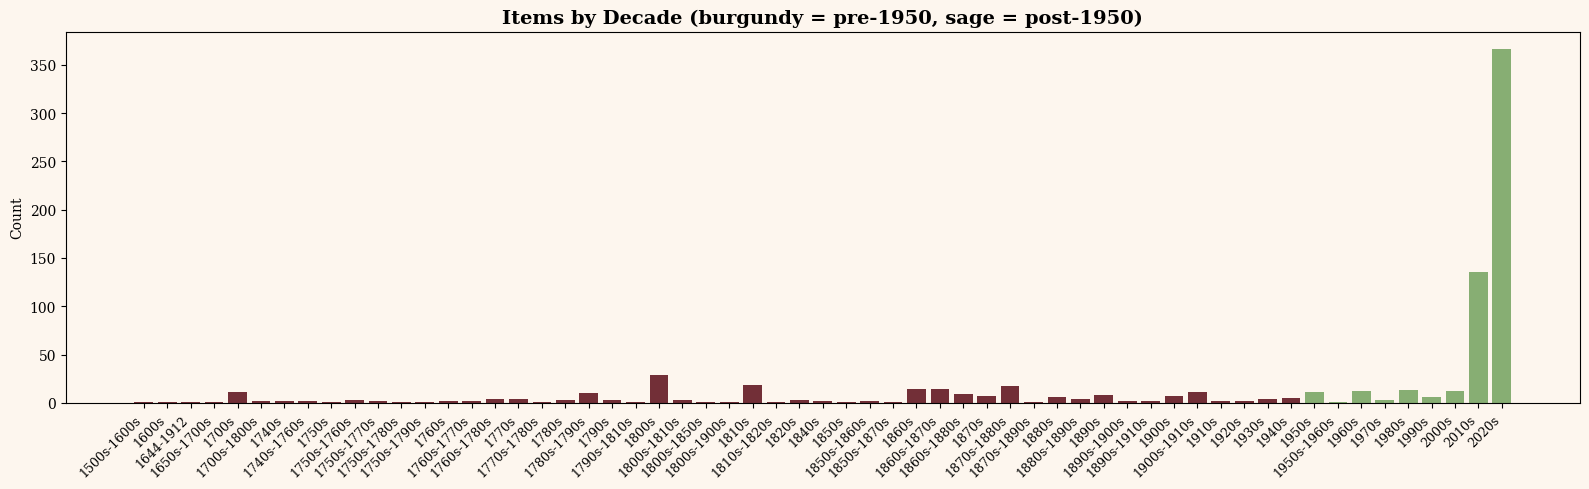


Total unique decades: 59
Earliest: 1500s-1600s
Latest: 2020s


In [36]:
# Decade distribution — where is our temporal coverage?
fig, ax = plt.subplots(figsize=(16, 5))

decade_counts = enriched['decade'].value_counts().sort_index()
# Try to sort chronologically
def decade_sort_key(d):
    if d is None or pd.isna(d):
        return 9999
    d_str = str(d).strip()
    for c in d_str:
        if c.isdigit():
            idx = d_str.index(c)
            try:
                return int(d_str[idx:idx+4])
            except:
                pass
    return 9999

sorted_decades = sorted(decade_counts.index, key=decade_sort_key)
decade_counts = decade_counts.reindex(sorted_decades)

colors = [VV_COLORS['burgundy'] if decade_sort_key(d) < 1950 else VV_COLORS['sage'] for d in decade_counts.index]
ax.bar(range(len(decade_counts)), decade_counts.values, color=colors)
ax.set_xticks(range(len(decade_counts)))
ax.set_xticklabels(decade_counts.index, rotation=45, ha='right', fontsize=9)
ax.set_title('Items by Decade (burgundy = pre-1950, sage = post-1950)', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(f'\nTotal unique decades: {enriched["decade"].nunique()}')
print(f'Earliest: {sorted_decades[0] if sorted_decades else "N/A"}')
print(f'Latest: {sorted_decades[-1] if sorted_decades else "N/A"}')

## 3. Taxonomy Distribution — Structural Fields

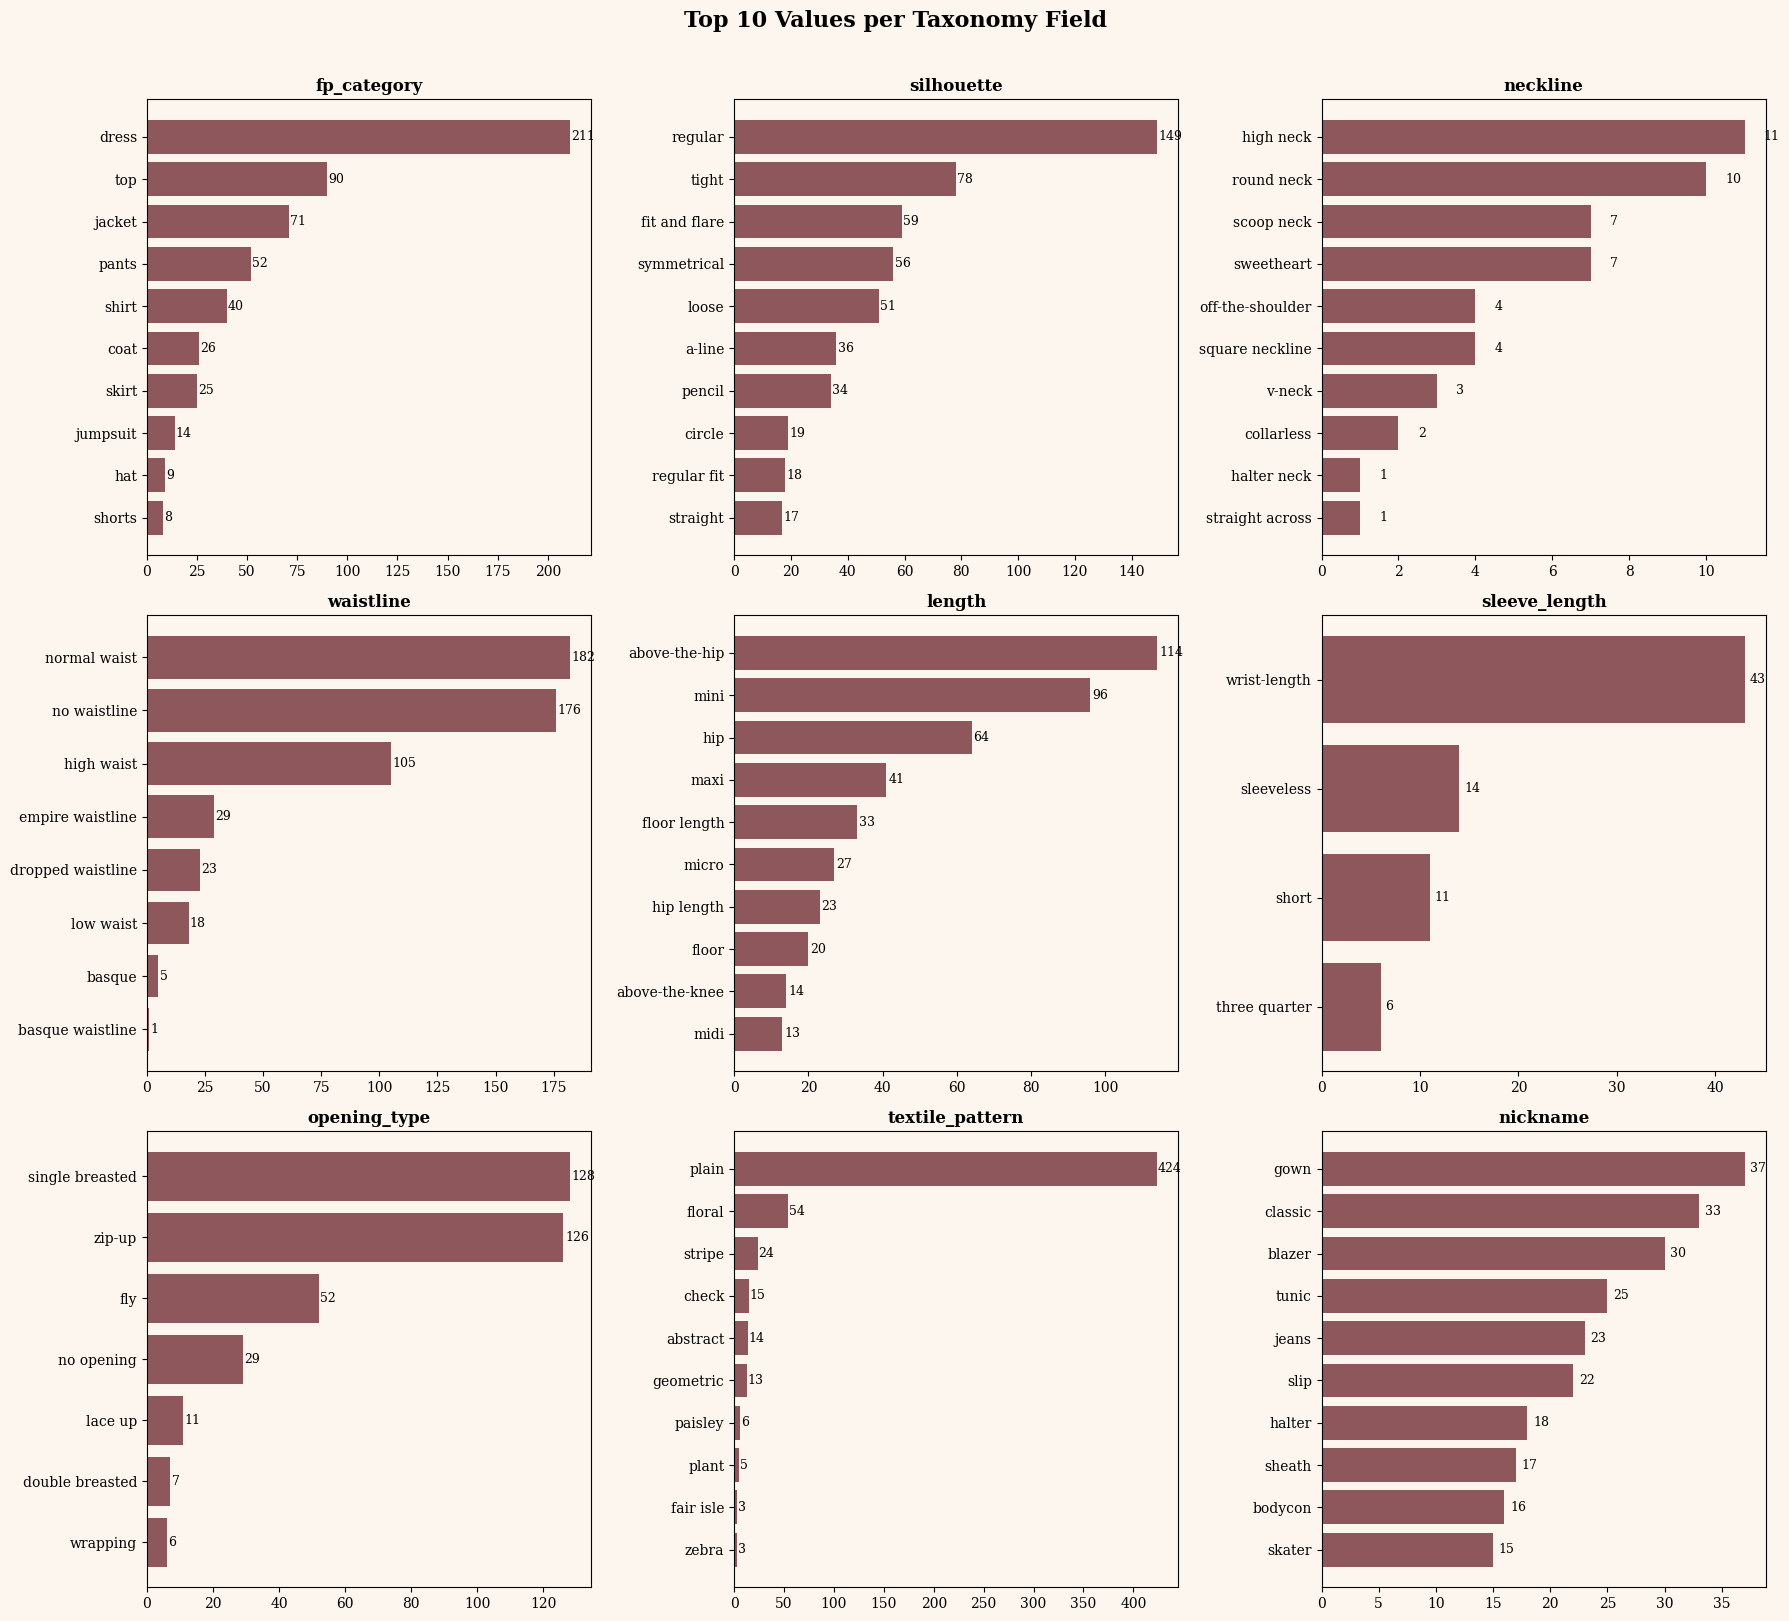

In [37]:
# Top values for each taxonomy field
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

for i, field in enumerate(taxonomy_fields):
    top = enriched[field].value_counts().head(10)
    if len(top) == 0:
        axes[i].text(0.5, 0.5, 'No data', ha='center', va='center', transform=axes[i].transAxes)
        axes[i].set_title(field, fontsize=12, fontweight='bold')
        continue
    axes[i].barh(top.index[::-1], top.values[::-1], color=VV_COLORS['burgundy'], alpha=0.8)
    axes[i].set_title(field, fontsize=12, fontweight='bold')
    for j, v in enumerate(top.values[::-1]):
        axes[i].text(v + 0.5, j, str(v), va='center', fontsize=9)

plt.suptitle('Top 10 Values per Taxonomy Field', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

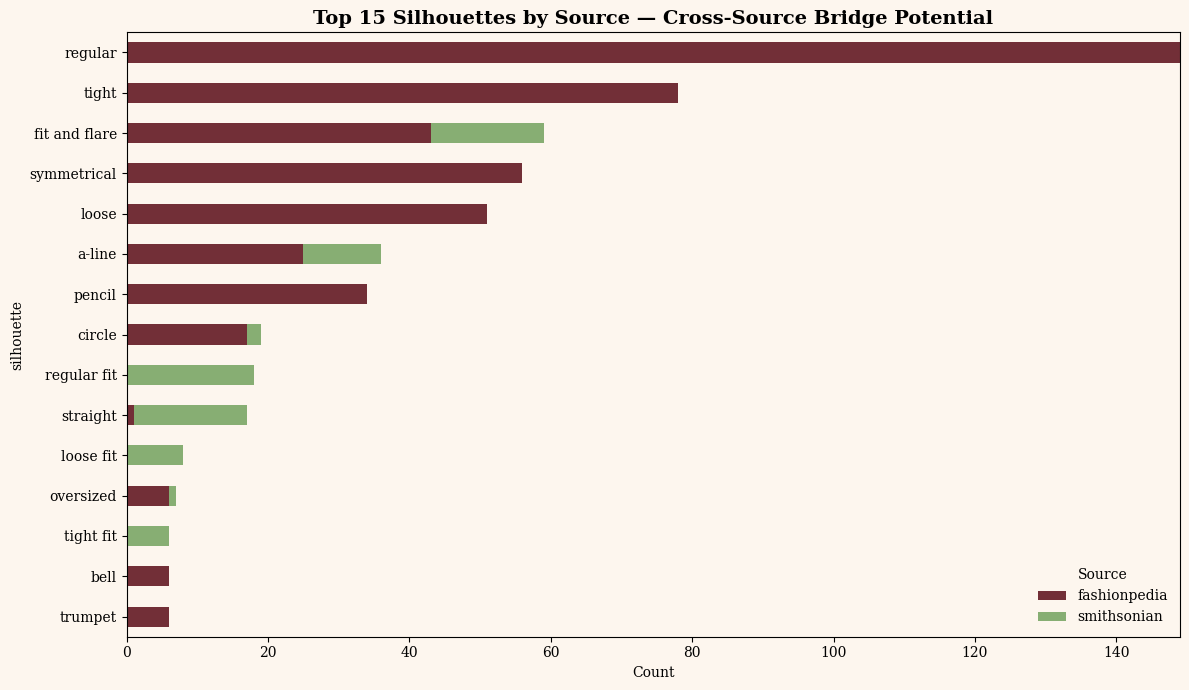


=== SILHOUETTES SHARED ACROSS HISTORICAL + MODERN ===
Historical sources have: 13 unique silhouettes
Modern source has: 18 unique silhouettes
Shared: 7 silhouettes

  ['a-line', 'circle', 'fit and flare', 'flare', 'mermaid', 'oversized', 'straight']


In [38]:
# Silhouette × Source — where do our sources overlap?
sil_plat = enriched.groupby(['silhouette', 'platform']).size().unstack(fill_value=0)
sil_plat['total'] = sil_plat.sum(axis=1)
sil_plat = sil_plat.sort_values('total', ascending=True).tail(15).drop('total', axis=1)

fig, ax = plt.subplots(figsize=(12, 7))
sil_plat.plot(kind='barh', stacked=True, ax=ax,
              color=[VV_COLORS['burgundy'], VV_COLORS['sage'], VV_COLORS['gold']])
ax.set_title('Top 15 Silhouettes by Source — Cross-Source Bridge Potential', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
ax.legend(title='Source', frameon=False)
plt.tight_layout()
plt.show()

# Which silhouettes appear in BOTH historical and modern sources?
print('\n=== SILHOUETTES SHARED ACROSS HISTORICAL + MODERN ===')
historical = set(enriched[enriched['platform'].isin(['met_museum', 'smithsonian'])]['silhouette'].dropna().unique())
modern = set(enriched[enriched['platform'] == 'fashionpedia']['silhouette'].dropna().unique())
shared = historical & modern
print(f'Historical sources have: {len(historical)} unique silhouettes')
print(f'Modern source has: {len(modern)} unique silhouettes')
print(f'Shared: {len(shared)} silhouettes')
print(f'\n  {sorted(shared)}')

## 4. Creative Fields — Vibes, Style Tags, Aesthetics

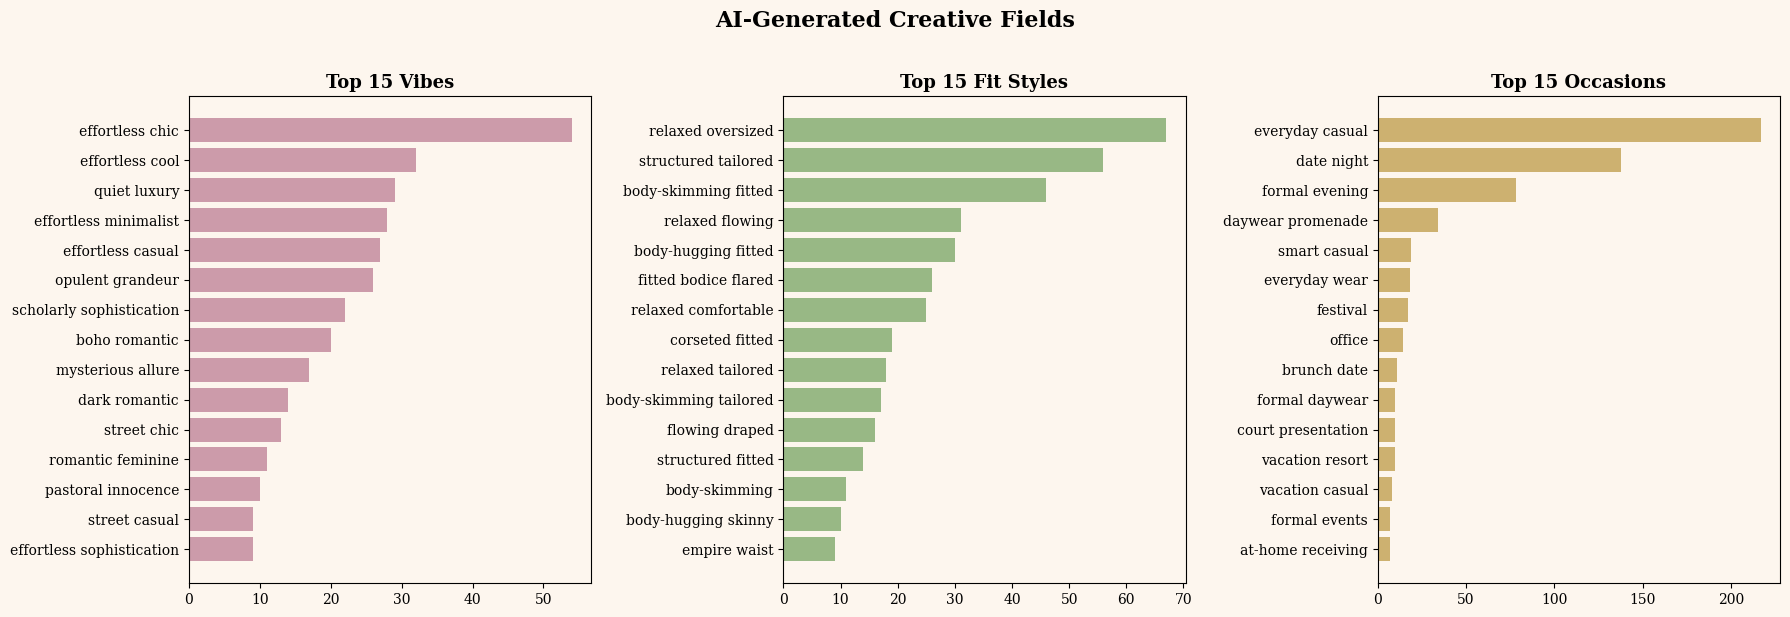

In [39]:
# Top vibes
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Vibe
top_vibes = enriched['vibe'].value_counts().head(15)
axes[0].barh(top_vibes.index[::-1], top_vibes.values[::-1], color=VV_COLORS['rose'], alpha=0.85)
axes[0].set_title('Top 15 Vibes', fontsize=13, fontweight='bold')

# Fit style
top_fits = enriched['fit_style'].value_counts().head(15)
axes[1].barh(top_fits.index[::-1], top_fits.values[::-1], color=VV_COLORS['sage'], alpha=0.85)
axes[1].set_title('Top 15 Fit Styles', fontsize=13, fontweight='bold')

# Occasion
top_occasions = enriched['occasion'].value_counts().head(15)
axes[2].barh(top_occasions.index[::-1], top_occasions.values[::-1], color=VV_COLORS['gold'], alpha=0.85)
axes[2].set_title('Top 15 Occasions', fontsize=13, fontweight='bold')

plt.suptitle('AI-Generated Creative Fields', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

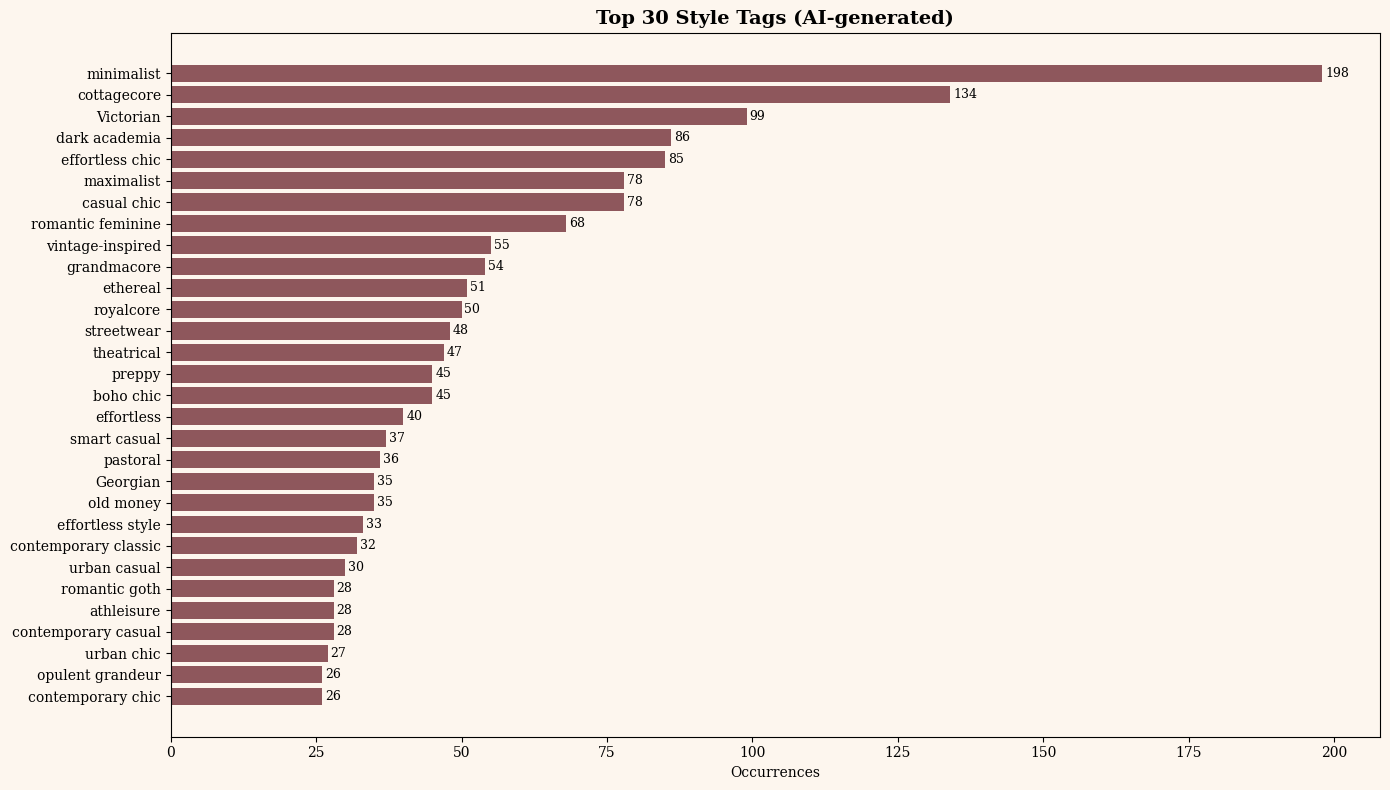


Total unique style tags: 710
Average tags per item: 4.4


In [40]:
# Style tags — explode the lists and count
all_tags = enriched['style_tags'].explode()
all_tags = all_tags[all_tags.notna() & (all_tags != '')]

tag_counts = all_tags.value_counts().head(30)

fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(tag_counts.index[::-1], tag_counts.values[::-1], color=VV_COLORS['burgundy'], alpha=0.8)
ax.set_title('Top 30 Style Tags (AI-generated)', fontsize=14, fontweight='bold')
ax.set_xlabel('Occurrences')
for i, v in enumerate(tag_counts.values[::-1]):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f'\nTotal unique style tags: {all_tags.nunique()}')
print(f'Average tags per item: {enriched["style_tags"].apply(len).mean():.1f}')

In [41]:
# Style tags by platform — what vibes does each source contribute?
print('=== TOP STYLE TAGS BY PLATFORM ===')
print()
for platform in enriched['platform'].unique():
    subset = enriched[enriched['platform'] == platform]
    tags = subset['style_tags'].explode()
    tags = tags[tags.notna() & (tags != '')]
    top = tags.value_counts().head(10)
    print(f'  {platform}:')
    for tag, count in top.items():
        print(f'    {tag:30s} {count}')
    print()

=== TOP STYLE TAGS BY PLATFORM ===

  met_museum:
    Victorian                      90
    cottagecore                    74
    grandmacore                    54
    maximalist                     45
    theatrical                     45
    pastoral                       36
    Georgian                       35
    ethereal                       33
    royalcore                      28
    opulent grandeur               26

  fashionpedia:
    minimalist                     193
    effortless chic                85
    casual chic                    78
    romantic feminine              56
    vintage-inspired               55
    streetwear                     47
    cottagecore                    46
    boho chic                      45
    dark academia                  41
    effortless                     40

  smithsonian:
    old money                      26
    maximalist                     26
    dark academia                  25
    royalcore                      22
    

## 5. Cross-Source Bridge Potential

Which taxonomy fields overlap between historical and modern sources? This tells us where cross-source bridges will be strongest.

In [42]:
# For each taxonomy field, compute overlap between historical and modern
historical_df = enriched[enriched['platform'].isin(['met_museum', 'smithsonian'])]
modern_df = enriched[enriched['platform'] == 'fashionpedia']

print('=== CROSS-SOURCE FIELD OVERLAP ===')
print(f'Historical items: {len(historical_df)}')
print(f'Modern items: {len(modern_df)}')
print()

overlap_data = []
for field in taxonomy_fields:
    hist_vals = set(historical_df[field].dropna().unique())
    mod_vals = set(modern_df[field].dropna().unique())
    shared = hist_vals & mod_vals
    total = hist_vals | mod_vals
    jaccard = len(shared) / len(total) if total else 0
    
    # Count items that could potentially bridge on this field
    hist_in_shared = historical_df[historical_df[field].isin(shared)].shape[0]
    mod_in_shared = modern_df[modern_df[field].isin(shared)].shape[0]
    
    overlap_data.append({
        'field': field,
        'historical_values': len(hist_vals),
        'modern_values': len(mod_vals),
        'shared_values': len(shared),
        'jaccard': jaccard,
        'hist_items_bridgeable': hist_in_shared,
        'mod_items_bridgeable': mod_in_shared,
    })
    
    print(f'  {field:20s}  historical: {len(hist_vals):3d}  modern: {len(mod_vals):3d}  '
          f'shared: {len(shared):3d}  Jaccard: {jaccard:.2f}  '
          f'bridgeable: {hist_in_shared}H + {mod_in_shared}M')

overlap_df = pd.DataFrame(overlap_data)

=== CROSS-SOURCE FIELD OVERLAP ===
Historical items: 298
Modern items: 500

  fp_category           historical:  15  modern:  16  shared:   7  Jaccard: 0.29  bridgeable: 71H + 334M
  silhouette            historical:  13  modern:  18  shared:   7  Jaccard: 0.29  bridgeable: 51H + 98M
  neckline              historical:  10  modern:   0  shared:   0  Jaccard: 0.00  bridgeable: 0H + 0M
  waistline             historical:   6  modern:   7  shared:   5  Jaccard: 0.62  bridgeable: 75H + 440M
  length                historical:   8  modern:  10  shared:   5  Jaccard: 0.38  bridgeable: 13H + 181M
  sleeve_length         historical:   4  modern:   0  shared:   0  Jaccard: 0.00  bridgeable: 0H + 0M
  opening_type          historical:   6  modern:   7  shared:   6  Jaccard: 0.86  bridgeable: 56H + 251M
  textile_pattern       historical:   8  modern:  19  shared:   7  Jaccard: 0.35  bridgeable: 97H + 442M
  nickname              historical:  19  modern:  55  shared:  10  Jaccard: 0.16  bridgeabl

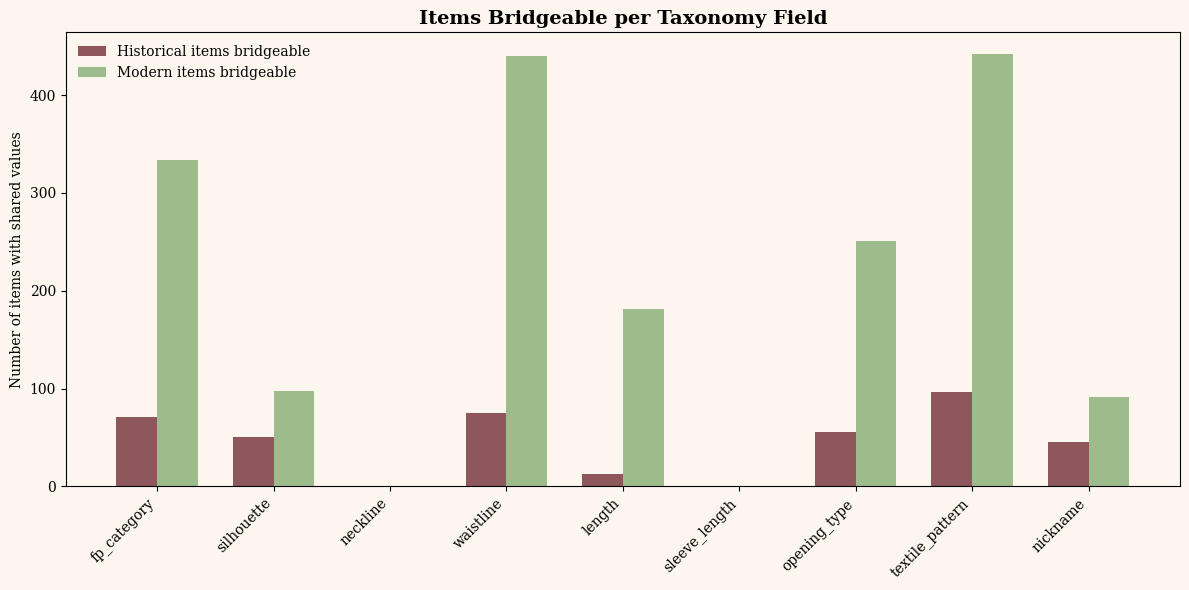

In [43]:
# Visualize bridge potential
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(overlap_df))
width = 0.35
ax.bar([i - width/2 for i in x], overlap_df['hist_items_bridgeable'], width,
       label='Historical items bridgeable', color=VV_COLORS['burgundy'], alpha=0.8)
ax.bar([i + width/2 for i in x], overlap_df['mod_items_bridgeable'], width,
       label='Modern items bridgeable', color=VV_COLORS['sage'], alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(overlap_df['field'], rotation=45, ha='right')
ax.set_title('Items Bridgeable per Taxonomy Field', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of items with shared values')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 6. Material & Textile Analysis

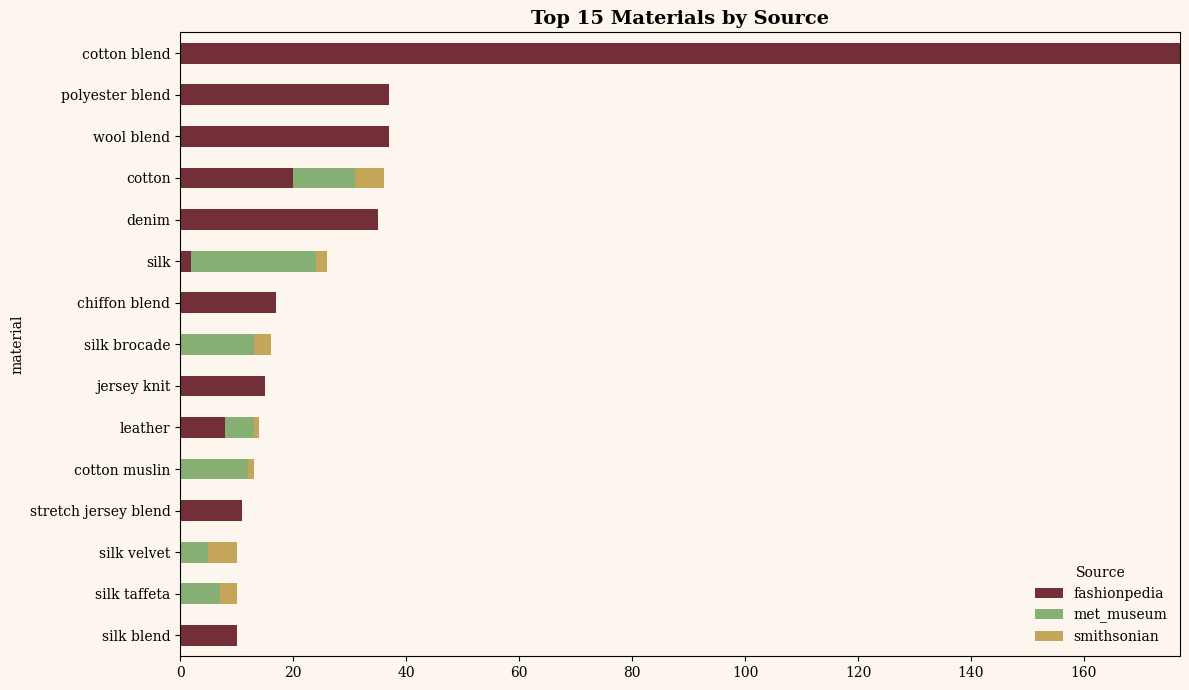

In [44]:
# Materials by era
mat_era = enriched[enriched['material'].notna()].groupby(['material', 'platform']).size().unstack(fill_value=0)
mat_era['total'] = mat_era.sum(axis=1)
top_materials = mat_era.sort_values('total', ascending=True).tail(15).drop('total', axis=1)

fig, ax = plt.subplots(figsize=(12, 7))
top_materials.plot(kind='barh', stacked=True, ax=ax,
                   color=[VV_COLORS['burgundy'], VV_COLORS['sage'], VV_COLORS['gold']])
ax.set_title('Top 15 Materials by Source', fontsize=14, fontweight='bold')
ax.legend(title='Source', frameon=False)
plt.tight_layout()
plt.show()

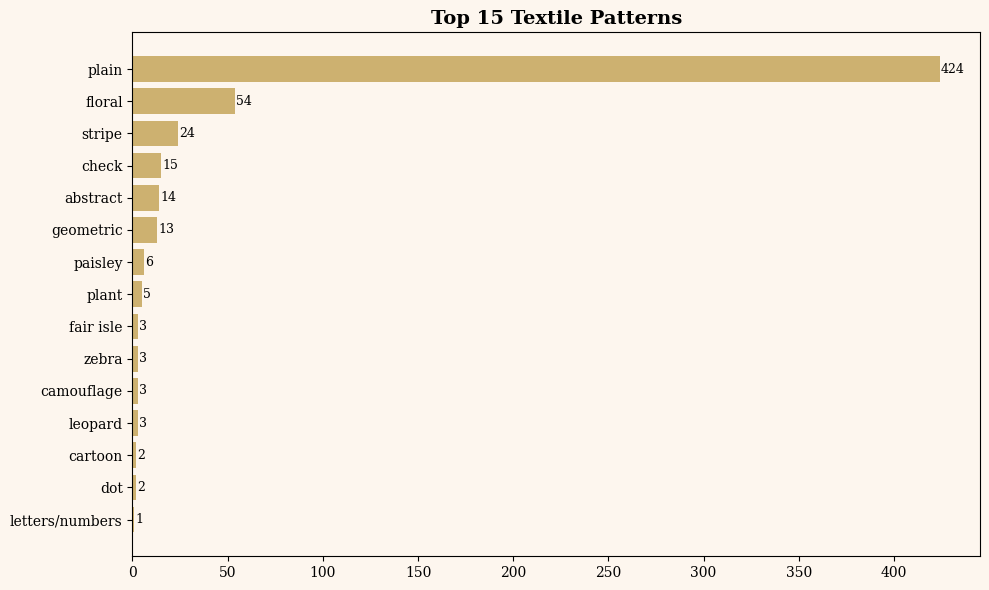

In [45]:
# Textile patterns
pat_counts = enriched['textile_pattern'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(pat_counts.index[::-1], pat_counts.values[::-1], color=VV_COLORS['gold'], alpha=0.85)
ax.set_title('Top 15 Textile Patterns', fontsize=14, fontweight='bold')
for i, v in enumerate(pat_counts.values[::-1]):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Sample Items — What Does the Enrichment Look Like?


  MET_MUSEUM


/var/folders/bj/6_c1hb753k563x1cm94gbf9h0000gq/T/ipykernel_37891/1308499759.py:49: LegacyAPIWarning: The Query.get() method is considered legacy as of the 1.x series of SQLAlchemy and becomes a legacy construct in 2.0. The method is now available as Session.get() (deprecated since: 2.0) (Background on SQLAlchemy 2.0 at: https://sqlalche.me/e/b8d9)
  product = db.query(Product).get(row['id'])



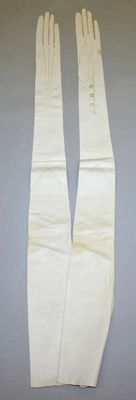


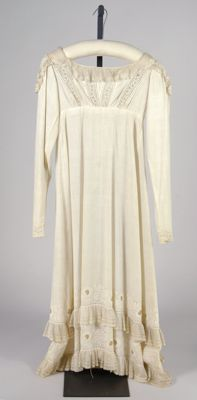


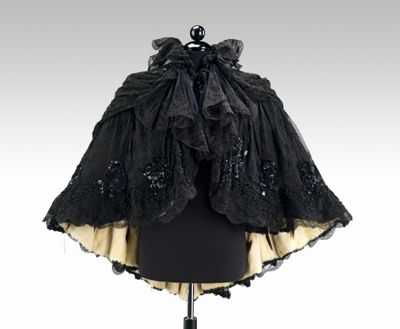


  SMITHSONIAN


/var/folders/bj/6_c1hb753k563x1cm94gbf9h0000gq/T/ipykernel_37891/1308499759.py:49: LegacyAPIWarning: The Query.get() method is considered legacy as of the 1.x series of SQLAlchemy and becomes a legacy construct in 2.0. The method is now available as Session.get() (deprecated since: 2.0) (Background on SQLAlchemy 2.0 at: https://sqlalche.me/e/b8d9)
  product = db.query(Product).get(row['id'])



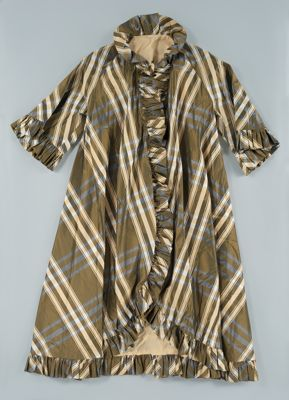


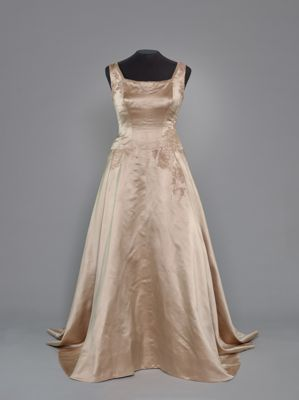


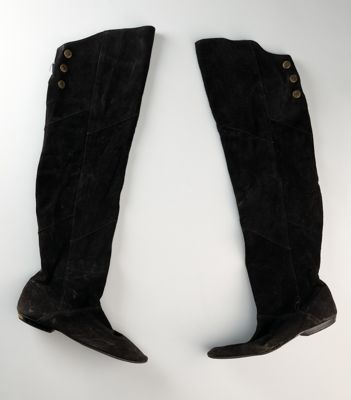


  FASHIONPEDIA


/var/folders/bj/6_c1hb753k563x1cm94gbf9h0000gq/T/ipykernel_37891/1308499759.py:49: LegacyAPIWarning: The Query.get() method is considered legacy as of the 1.x series of SQLAlchemy and becomes a legacy construct in 2.0. The method is now available as Session.get() (deprecated since: 2.0) (Background on SQLAlchemy 2.0 at: https://sqlalche.me/e/b8d9)
  product = db.query(Product).get(row['id'])



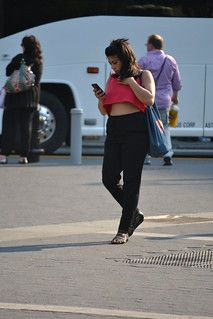


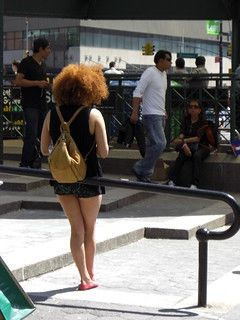


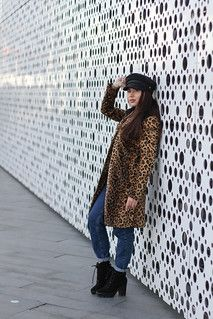

In [46]:
# Show a few sample items from each platform with their enrichment
from IPython.display import display, HTML
import base64

def show_item(row, product):
    """Display an item with its image and enrichment."""
    html = f'<div style="display:flex; gap:20px; margin:20px 0; padding:15px; background:#fdf6ee; border-radius:8px; border:1px solid #d4c5b0;">'
    
    # Image
    if product.primary_image and product.primary_image.startswith('data:'):
        html += f'<img src="{product.primary_image}" style="width:200px; height:200px; object-fit:cover; border-radius:4px;"/>'
    else:
        html += '<div style="width:200px;height:200px;background:#d4c5b0;border-radius:4px;display:flex;align-items:center;justify-content:center;">No Image</div>'
    
    # Metadata
    html += '<div style="flex:1;">'
    html += f'<h3 style="margin:0 0 5px 0; color:#722f37;">{row["title"]}</h3>'
    html += f'<p style="margin:0 0 8px 0; color:#8b7d6b; font-size:13px;">{row["platform"]} | {row["era"]} ({row["decade"]})</p>'
    
    # Style tags as badges
    if row['style_tags']:
        tags_html = ' '.join(f'<span style="background:#722f37;color:white;padding:2px 8px;border-radius:10px;font-size:11px;margin:2px;">{t}</span>' for t in row['style_tags'][:5])
        html += f'<p style="margin:4px 0;">{tags_html}</p>'
    
    # Key fields
    fields = []
    for f in ['silhouette', 'neckline', 'material', 'vibe', 'occasion', 'fp_category']:
        if row.get(f):
            fields.append(f'<b>{f}:</b> {row[f]}')
    if fields:
        html += f'<p style="font-size:12px; color:#555; margin:4px 0;">{", ".join(fields)}</p>'
    
    # AI description
    if product.ai_description:
        desc = product.ai_description[:200] + '...' if len(product.ai_description) > 200 else product.ai_description
        html += f'<p style="font-size:12px; color:#666; margin:8px 0; font-style:italic;">"{desc}"</p>'
    
    html += '</div></div>'
    display(HTML(html))

# Show 2 from each platform
for platform in ['met_museum', 'smithsonian', 'fashionpedia']:
    print(f'\n{"=" * 60}')
    print(f'  {platform.upper()}')
    print(f'{"=" * 60}')
    subset = df[df['platform'] == platform]
    samples = subset[subset['has_enrichment']].sample(n=min(3, len(subset)), random_state=42)
    for _, row in samples.iterrows():
        product = db.query(Product).get(row['id'])
        show_item(row, product)

## 8. Data Quality Signals

In [47]:
# Check for suspicious patterns in the enrichment
print('=== DATA QUALITY CHECKS ===')
print()

# 1. Era consistency — do museum items get classified as modern?
hist_modern = historical_df[historical_df['era'].str.contains('Modern|Contemporary|2000|2010|2020', na=False, case=False)]
print(f'1. Historical items classified as modern era: {len(hist_modern)}')
if len(hist_modern) > 0:
    for _, row in hist_modern.head(5).iterrows():
        print(f'   - [{row["platform"]}] "{row["title"]}" → era: {row["era"]}, decade: {row["decade"]}')
print()

# 2. Fashionpedia items — do they get reasonable eras?
fp_eras = modern_df['era'].value_counts()
print(f'2. Fashionpedia era distribution:')
for era, count in fp_eras.head(10).items():
    print(f'   {era}: {count}')
print()

# 3. Null enrichment fields on enriched items
enriched_items = df[df['has_enrichment']]
print(f'3. Null rates on enriched items:')
for field in ['era', 'vibe', 'silhouette', 'ai_description']:
    null_rate = enriched_items[field].isna().mean() * 100
    if field == 'ai_description':
        null_rate = (~enriched_items['has_ai_description']).mean() * 100
    print(f'   {field:20s} {null_rate:5.1f}% null')
print()

# 4. Style tag diversity
print(f'4. Style tag stats:')
tag_lengths = enriched_items['style_tags'].apply(len)
print(f'   Mean tags per item: {tag_lengths.mean():.1f}')
print(f'   Min: {tag_lengths.min()}, Max: {tag_lengths.max()}')
print(f'   Items with 0 tags: {(tag_lengths == 0).sum()}')

=== DATA QUALITY CHECKS ===

1. Historical items classified as modern era: 51
   - [smithsonian] "Miniature copy of First Lady Truman's evening gown by Ann Lowe" → era: Mid-Century Modern, decade: 1960s
   - [met_museum] "Dress" → era: Mid-Century Modern, decade: 1950s
   - [smithsonian] "Black dress with blue embroidered puff sleeved and peplum" → era: Contemporary, decade: 1980s
   - [smithsonian] "Dress designed by Ann Lowe" → era: Mid-Century Modern, decade: 1950s
   - [smithsonian] "Dress designed by Ann Lowe" → era: Mid-Century Modern, decade: 1960s

2. Fashionpedia era distribution:
   Modern: 491
   1970s-inspired: 3
   1940s-inspired: 2
   1990s-inspired: 1
   1950s-inspired: 1
   1960s-inspired: 1
   Victorian-inspired: 1

3. Null rates on enriched items:
   era                    0.0% null
   vibe                   0.0% null
   silhouette            28.3% null
   ai_description         0.0% null

4. Style tag stats:
   Mean tags per item: 4.4
   Min: 4, Max: 5
   Items with 

## 9. Co-occurrence Patterns — What Goes With What?

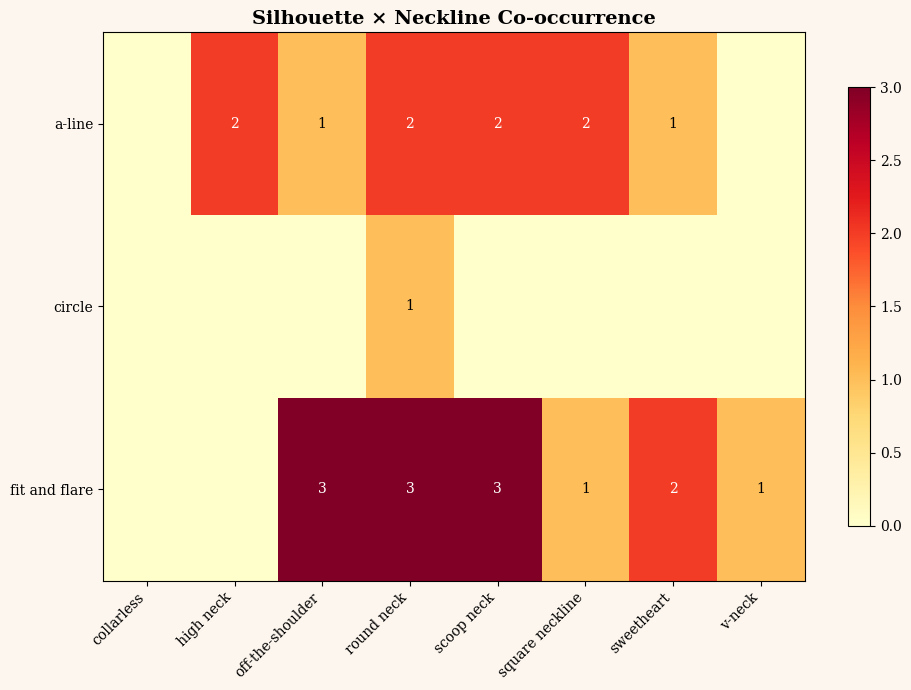

In [48]:
# Silhouette × Neckline heatmap
cross = pd.crosstab(enriched['silhouette'], enriched['neckline'])
# Keep top values only
top_sil = enriched['silhouette'].value_counts().head(8).index
top_neck = enriched['neckline'].value_counts().head(8).index
cross_top = cross.loc[cross.index.isin(top_sil), cross.columns.isin(top_neck)]

if cross_top.shape[0] > 0 and cross_top.shape[1] > 0:
    fig, ax = plt.subplots(figsize=(10, 7))
    im = ax.imshow(cross_top.values, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(cross_top.columns)))
    ax.set_xticklabels(cross_top.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(cross_top.index)))
    ax.set_yticklabels(cross_top.index)
    ax.set_title('Silhouette × Neckline Co-occurrence', fontsize=14, fontweight='bold')
    
    # Add counts
    for i in range(len(cross_top.index)):
        for j in range(len(cross_top.columns)):
            val = cross_top.values[i, j]
            if val > 0:
                ax.text(j, i, str(val), ha='center', va='center', fontsize=10,
                       color='white' if val > cross_top.values.max()/2 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()
else:
    print('Not enough data for silhouette × neckline heatmap')

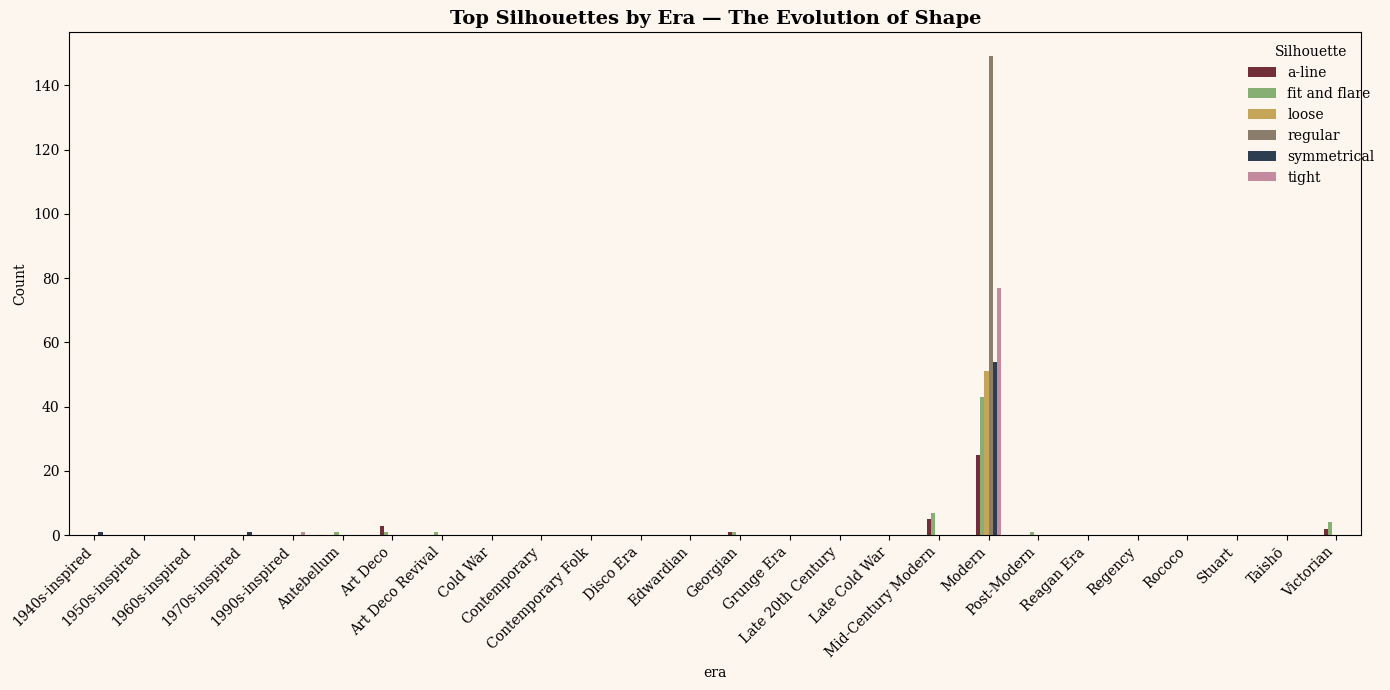

In [50]:
# Era × Silhouette — how silhouettes evolve across time
era_sil = enriched[enriched['silhouette'].notna() & enriched['era'].notna()]
cross2 = pd.crosstab(era_sil['era'], era_sil['silhouette'])

top_sil = enriched['silhouette'].value_counts().head(6).index
cross2_top = cross2.loc[:, cross2.columns.isin(top_sil)]

if cross2_top.shape[0] > 0:
    fig, ax = plt.subplots(figsize=(14, 7))
    cross2_top.plot(kind='bar', ax=ax, color=PALETTE[:len(cross2_top.columns)])
    ax.set_title('Top Silhouettes by Era — The Evolution of Shape', fontsize=14, fontweight='bold')
    ax.set_ylabel('Count')
    ax.legend(title='Silhouette', frameon=False, bbox_to_anchor=(1.02, 1))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 10. Summary Stats

In [51]:
print('=' * 60)
print('  VINTAGE VESTIGE — ENRICHED DATA SUMMARY')
print('=' * 60)
print()
print(f'Total items:              {len(df)}')
print(f'Enriched items:           {df["has_enrichment"].sum()}')
print(f'Items with images:        {df["has_image"].sum()}')
print(f'Items with AI description: {df["has_ai_description"].sum()}')
print()
print(f'Sources:                  {df["platform"].nunique()}')
for p in df['platform'].unique():
    print(f'  - {p}: {len(df[df["platform"]==p])}')
print()
print(f'Unique eras:              {enriched["era"].nunique()}')
print(f'Unique decades:           {enriched["decade"].nunique()}')
print(f'Unique silhouettes:       {enriched["silhouette"].nunique()}')
print(f'Unique necklines:         {enriched["neckline"].nunique()}')
print(f'Unique materials:         {enriched["material"].nunique()}')
print(f'Unique style tags:        {all_tags.nunique()}')
print(f'Unique vibes:             {enriched["vibe"].nunique()}')
print()
print(f'Cross-source bridge potential:')
print(f'  Shared silhouettes:     {len(shared)} values across historical + modern')
print(f'  Historical items bridgeable: {historical_df[historical_df["silhouette"].isin(shared)].shape[0]}')
print(f'  Modern items bridgeable:     {modern_df[modern_df["silhouette"].isin(shared)].shape[0]}')

db.close()

  VINTAGE VESTIGE — ENRICHED DATA SUMMARY

Total items:              952
Enriched items:           798
Items with images:        952
Items with AI description: 798

Sources:                  3
  - smithsonian: 252
  - met_museum: 200
  - fashionpedia: 500

Unique eras:              40
Unique decades:           59
Unique silhouettes:       24
Unique necklines:         10
Unique materials:         241
Unique style tags:        710
Unique vibes:             297

Cross-source bridge potential:
  Shared silhouettes:     10 values across historical + modern
  Historical items bridgeable: 0
  Modern items bridgeable:     0
